# NB02: Growth Kinetics Analysis

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Extract growth parameters from fitted curves and compute kinetic advantage scores vs PA14.

A commensal that grows *faster* on a shared substrate depletes it before PA14 can ramp up. Growth rate may predict competitive outcomes better than endpoint OD.

## Data Structure
- `fact_growth_curves_fitted`: 32 isolates × 22 conditions × 2 assays (Dropout, Single carbon)
- ~500-1000 fitted OD points per curve over 193 cycles
- Conditions: 20 amino acids + glucose + lactate + SCFM
- PA14_KEH108_Reporter included as reference pathogen

**Input**: `~/protect/gold/fact_growth_curves_fitted.snappy.parquet`  
**Output**: `data/growth_parameters.tsv`, `data/kinetic_advantage.tsv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
DATA.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

gc = pd.read_parquet(GOLD / 'fact_growth_curves_fitted.snappy.parquet')
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')

print(f'Growth curves: {len(gc):,} fitted points')
print(f'Isolates: {gc.asma_id.nunique()} (including PA14 reporter)')
print(f'Assays: {sorted(gc.assay.unique())}')
print(f'Conditions: {sorted(gc.condition.unique())}')
print(f'Cycle range: {gc.cycle.min():.0f}–{gc.cycle.max():.0f}')

Growth curves: 676,000 fitted points
Isolates: 32 (including PA14 reporter)
Assays: ['Dropout', 'Single carbon']
Conditions: ['Alanine', 'Arginine', 'Aspartate', 'Cysteine', 'Glucose', 'Glutamate', 'Glycine', 'Histidine', 'Isoleucine', 'Lactate', 'Leucine', 'Lysine', 'Methionine', 'Ornithine', 'Phenylalanine', 'Proline', 'SCFM', 'Serine', 'Threonine', 'Tryptophan', 'Tyrosine', 'Valine']
Cycle range: 1–193


## 1. Growth Curve Gallery

Visualize PA14 vs a selection of commensals across carbon sources to build intuition about the kinetic differences.

Single carbon assay: 327,500 points, 32 isolates


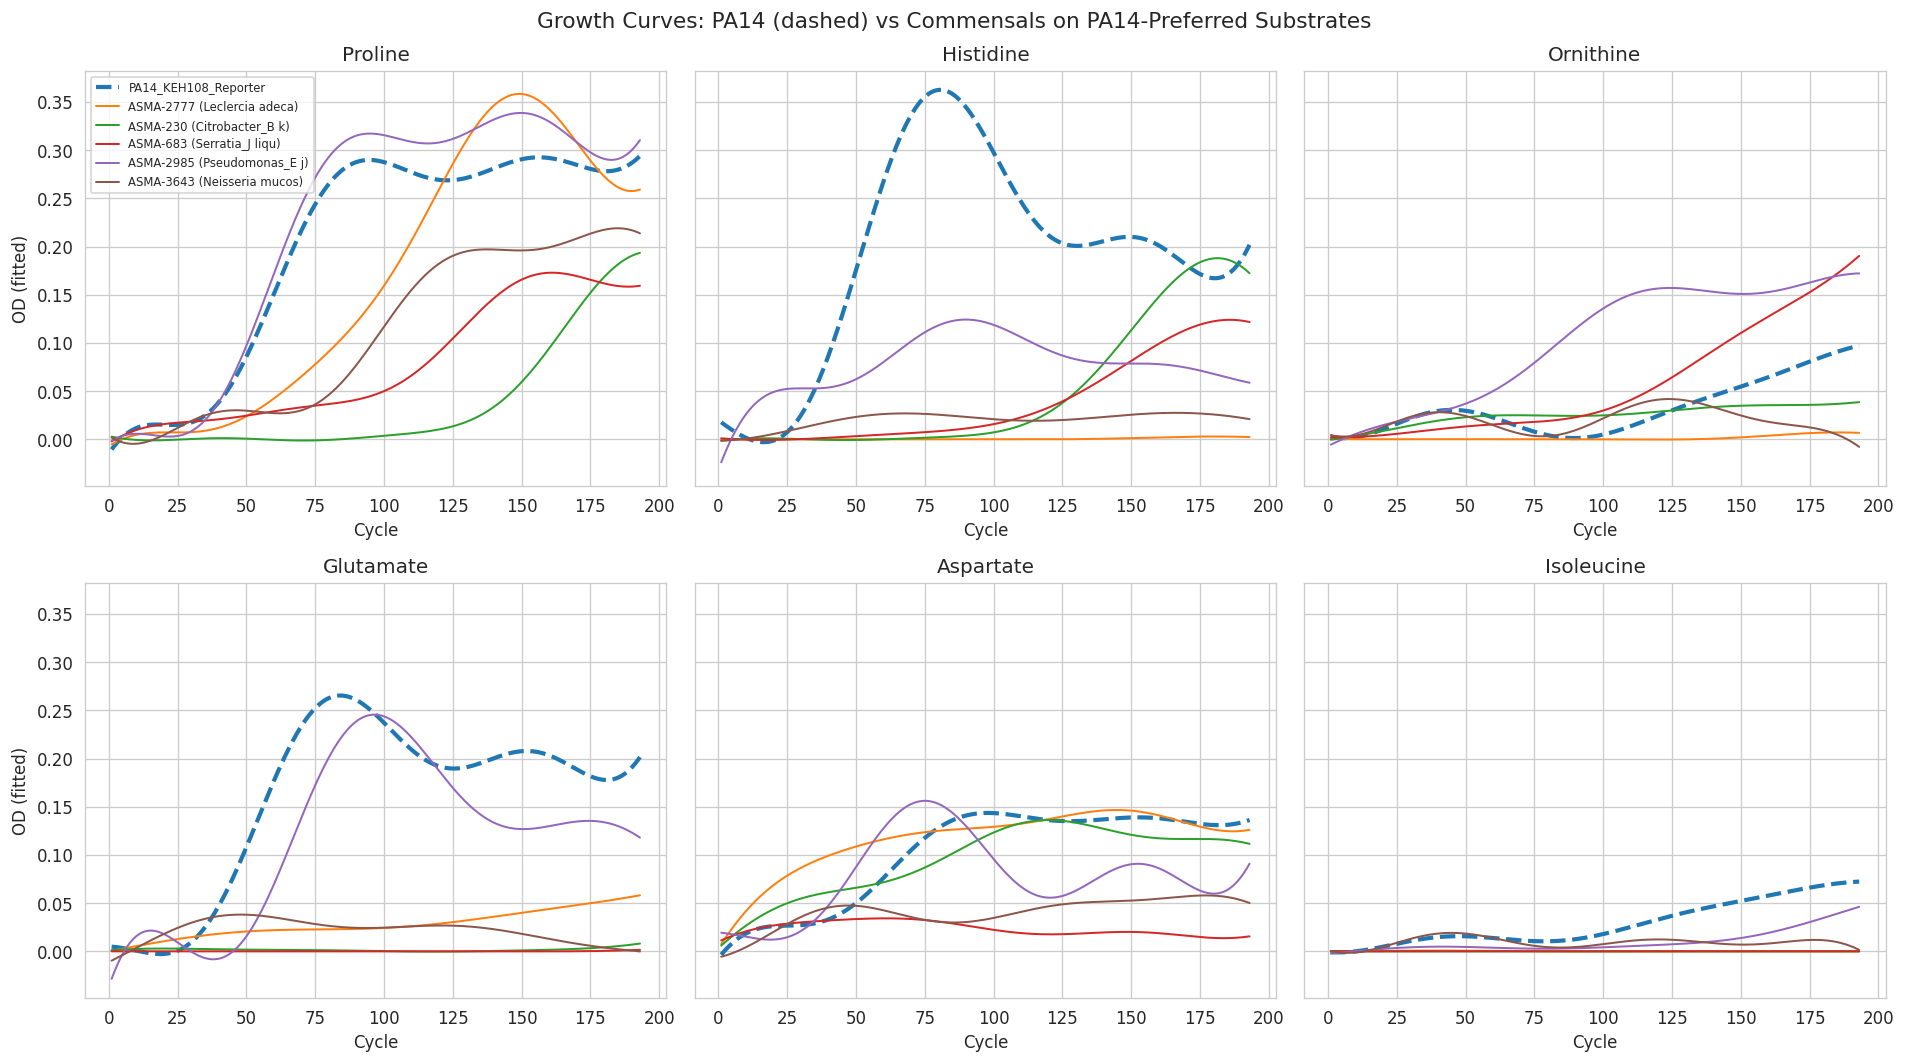

In [2]:
# Use 'Single carbon' assay for direct comparison (cleaner signal)
gc_sc = gc[gc.assay == 'Single carbon'].copy()
print(f'Single carbon assay: {len(gc_sc):,} points, {gc_sc.asma_id.nunique()} isolates')

# PA14's preferred substrates
pa14_preferred = ['Proline', 'Histidine', 'Ornithine', 'Glutamate', 'Aspartate', 
                  'Isoleucine', 'Arginine', 'Lactate', 'Leucine', 'Glucose']

# Pick a few commensals with good inhibition + growth data
gc_tax = gc_sc.merge(isolates[['asma_id','species']], on='asma_id', how='left')
# Show PA14 + 5 representative commensals
show_isolates = ['PA14_KEH108_Reporter', 'ASMA-2777', 'ASMA-230', 'ASMA-683', 'ASMA-2985', 'ASMA-3643']
show_data = gc_tax[gc_tax.asma_id.isin(show_isolates) & gc_tax.condition.isin(pa14_preferred[:6])]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for i, cond in enumerate(pa14_preferred[:6]):
    ax = axes.flat[i]
    for iso_id in show_isolates:
        d = show_data[(show_data.asma_id == iso_id) & (show_data.condition == cond)]
        if len(d) == 0:
            continue
        label = iso_id if 'PA14' in iso_id else f"{iso_id} ({d.species.iloc[0][:15]})"
        lw = 2.5 if 'PA14' in iso_id else 1.2
        ls = '--' if 'PA14' in iso_id else '-'
        ax.plot(d.cycle, d.od_fit, label=label, linewidth=lw, linestyle=ls)
    ax.set_title(cond)
    ax.set_xlabel('Cycle')
    if i % 3 == 0:
        ax.set_ylabel('OD (fitted)')

axes.flat[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Growth Curves: PA14 (dashed) vs Commensals on PA14-Preferred Substrates', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / '02_growth_curve_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Extract Growth Parameters

For each isolate × condition, extract:
- **Carrying capacity (K)**: max OD reached
- **Max growth rate (μ_max)**: steepest slope
- **Lag time (λ)**: time before growth exceeds 10% of max rate
- **AUC**: area under the curve (total biomass accumulated)

In [3]:
def extract_params(group):
    """Extract growth parameters from a single isolate x condition curve."""
    d = group.sort_values('cycle')
    t = d.cycle.values
    od = d.od_fit.values
    
    # Carrying capacity
    K = np.max(od)
    
    # AUC (trapezoidal)
    auc = np.trapz(np.maximum(od, 0), t)
    
    # Growth rate: max derivative (smoothed)
    if len(od) >= 11:
        od_s = savgol_filter(od, 11, 3)
    else:
        od_s = od
    dt = np.diff(t)
    dt[dt == 0] = 1e-6
    dod = np.diff(od_s) / dt
    mu_max = np.max(dod) if len(dod) > 0 else 0
    
    # Lag time: cycle when growth rate first exceeds 10% of max
    if mu_max > 0:
        thresh = 0.1 * mu_max
        above = np.where(dod > thresh)[0]
        lag = t[above[0]] if len(above) > 0 else t[-1]
    else:
        lag = t[-1]  # no growth
    
    return pd.Series({'K': K, 'mu_max': mu_max, 'lag': lag, 'auc': auc})

# Extract for Single carbon assay
print('Extracting growth parameters (Single carbon assay)...')
params_sc = gc_sc.groupby(['asma_id', 'condition']).apply(extract_params).reset_index()
print(f'Parameters extracted: {len(params_sc)} isolate × condition combinations')
params_sc.head(10)

Extracting growth parameters (Single carbon assay)...


Parameters extracted: 655 isolate × condition combinations


,asma_id,condition,K,mu_max,lag,auc
0,ASMA-1153,Alanine,0.268754,4.243377e-03,19.084168,18.709785
1,ASMA-1153,Arginine,0.000530,1.714853e-06,60.254509,0.010680
2,ASMA-1153,Aspartate,0.314822,5.248335e-03,1.000000,20.868847
3,ASMA-1153,Cysteine,0.047290,4.327499e-04,1.000000,5.017465
4,ASMA-1153,Glucose,0.206672,6.305221e-03,1.000000,29.962086
5,ASMA-1153,Glutamate,0.005581,1.889354e-04,105.657315,0.227047
6,ASMA-1153,Glycine,0.000022,1.654974e-07,51.020040,0.000376
7,ASMA-1153,Histidine,0.012563,2.787403e-04,78.338677,0.737992
8,ASMA-1153,Isoleucine,0.000844,2.454285e-05,1.000000,0.024768
9,ASMA-1153,Lactate,0.271542,5.705684e-03,9.464930,32.142126


In [4]:
# Also extract for Dropout assay
gc_do = gc[gc.assay == 'Dropout'].copy()
print(f'Extracting Dropout assay parameters...')
params_do = gc_do.groupby(['asma_id', 'condition']).apply(extract_params).reset_index()
params_do['assay'] = 'Dropout'
params_sc_labeled = params_sc.copy()
params_sc_labeled['assay'] = 'Single carbon'

params_all = pd.concat([params_sc_labeled, params_do], ignore_index=True)
print(f'Total: {len(params_all)} parameter sets ({params_all.asma_id.nunique()} isolates)')

# Summary stats
print(f'\nParameter distributions (Single carbon):')
print(params_sc[['K', 'mu_max', 'lag', 'auc']].describe().round(4).to_string())

Extracting Dropout assay parameters...


Total: 1352 parameter sets (32 isolates)

Parameter distributions (Single carbon):
              K    mu_max       lag       auc
count  655.0000  655.0000  655.0000  655.0000
mean     0.0881    0.0019   17.4705    9.8903
std      0.1566    0.0037   32.7631   20.3101
min      0.0000   -0.0000    1.0000    0.0000
25%      0.0074    0.0002    1.0000    0.4851
50%      0.0302    0.0006    1.0000    2.8007
75%      0.0941    0.0019   15.6212    9.4814
max      1.2244    0.0392  193.0000  173.1543


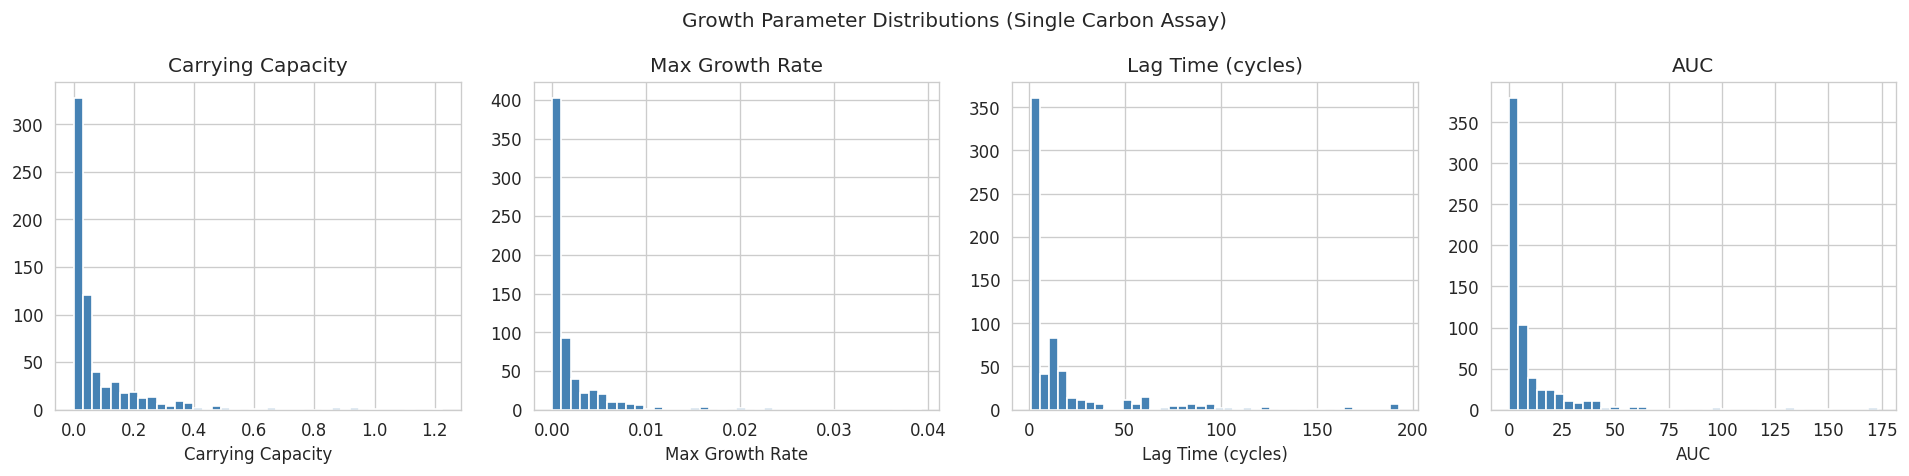

In [5]:
# Parameter distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (param, label) in enumerate([('K', 'Carrying Capacity'), ('mu_max', 'Max Growth Rate'),
                                     ('lag', 'Lag Time (cycles)'), ('auc', 'AUC')]):
    ax = axes[i]
    params_sc[param].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel(label)
    ax.set_title(label)
plt.suptitle('Growth Parameter Distributions (Single Carbon Assay)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / '02_parameter_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Kinetic Advantage vs PA14

For each commensal and each carbon source, how does it compare to PA14?

In [6]:
# PA14 parameters
pa14_params = params_sc[params_sc.asma_id == 'PA14_KEH108_Reporter'].set_index('condition')
commensal_params = params_sc[params_sc.asma_id != 'PA14_KEH108_Reporter'].copy()

# Compute advantages
advantages = []
for _, row in commensal_params.iterrows():
    cond = row['condition']
    if cond not in pa14_params.index:
        continue
    pa = pa14_params.loc[cond]
    
    # Rate advantage: commensal mu_max / PA14 mu_max (>1 = faster)
    rate_adv = row['mu_max'] / pa['mu_max'] if pa['mu_max'] > 0.001 else np.nan
    # Lag advantage: PA14 lag - commensal lag (>0 = starts sooner)
    lag_adv = pa['lag'] - row['lag']
    # Capacity advantage
    cap_adv = row['K'] / pa['K'] if pa['K'] > 0.01 else np.nan
    # AUC advantage
    auc_adv = row['auc'] / pa['auc'] if pa['auc'] > 0.01 else np.nan
    
    advantages.append({
        'asma_id': row['asma_id'], 'condition': cond,
        'mu_max_comm': row['mu_max'], 'mu_max_pa14': pa['mu_max'],
        'K_comm': row['K'], 'K_pa14': pa['K'],
        'lag_comm': row['lag'], 'lag_pa14': pa['lag'],
        'rate_advantage': rate_adv, 'lag_advantage': lag_adv,
        'capacity_advantage': cap_adv, 'auc_advantage': auc_adv
    })

adv = pd.DataFrame(advantages)
adv = adv.merge(isolates[['asma_id','species','genus']], on='asma_id', how='left')
print(f'Kinetic comparisons: {len(adv)} (isolate × condition pairs)')
print(f'Isolates: {adv.asma_id.nunique()}')

# Summary: how often do commensals beat PA14?
print(f'\nRate advantage > 1 (faster than PA14): {(adv.rate_advantage > 1).sum()} / {adv.rate_advantage.notna().sum()} = {(adv.rate_advantage > 1).mean():.1%}')
print(f'Lag advantage > 0 (starts before PA14): {(adv.lag_advantage > 0).sum()} / {adv.lag_advantage.notna().sum()} = {(adv.lag_advantage > 0).mean():.1%}')

Kinetic comparisons: 654 (isolate × condition pairs)
Isolates: 31

Rate advantage > 1 (faster than PA14): 90 / 509 = 13.8%
Lag advantage > 0 (starts before PA14): 282 / 654 = 43.1%


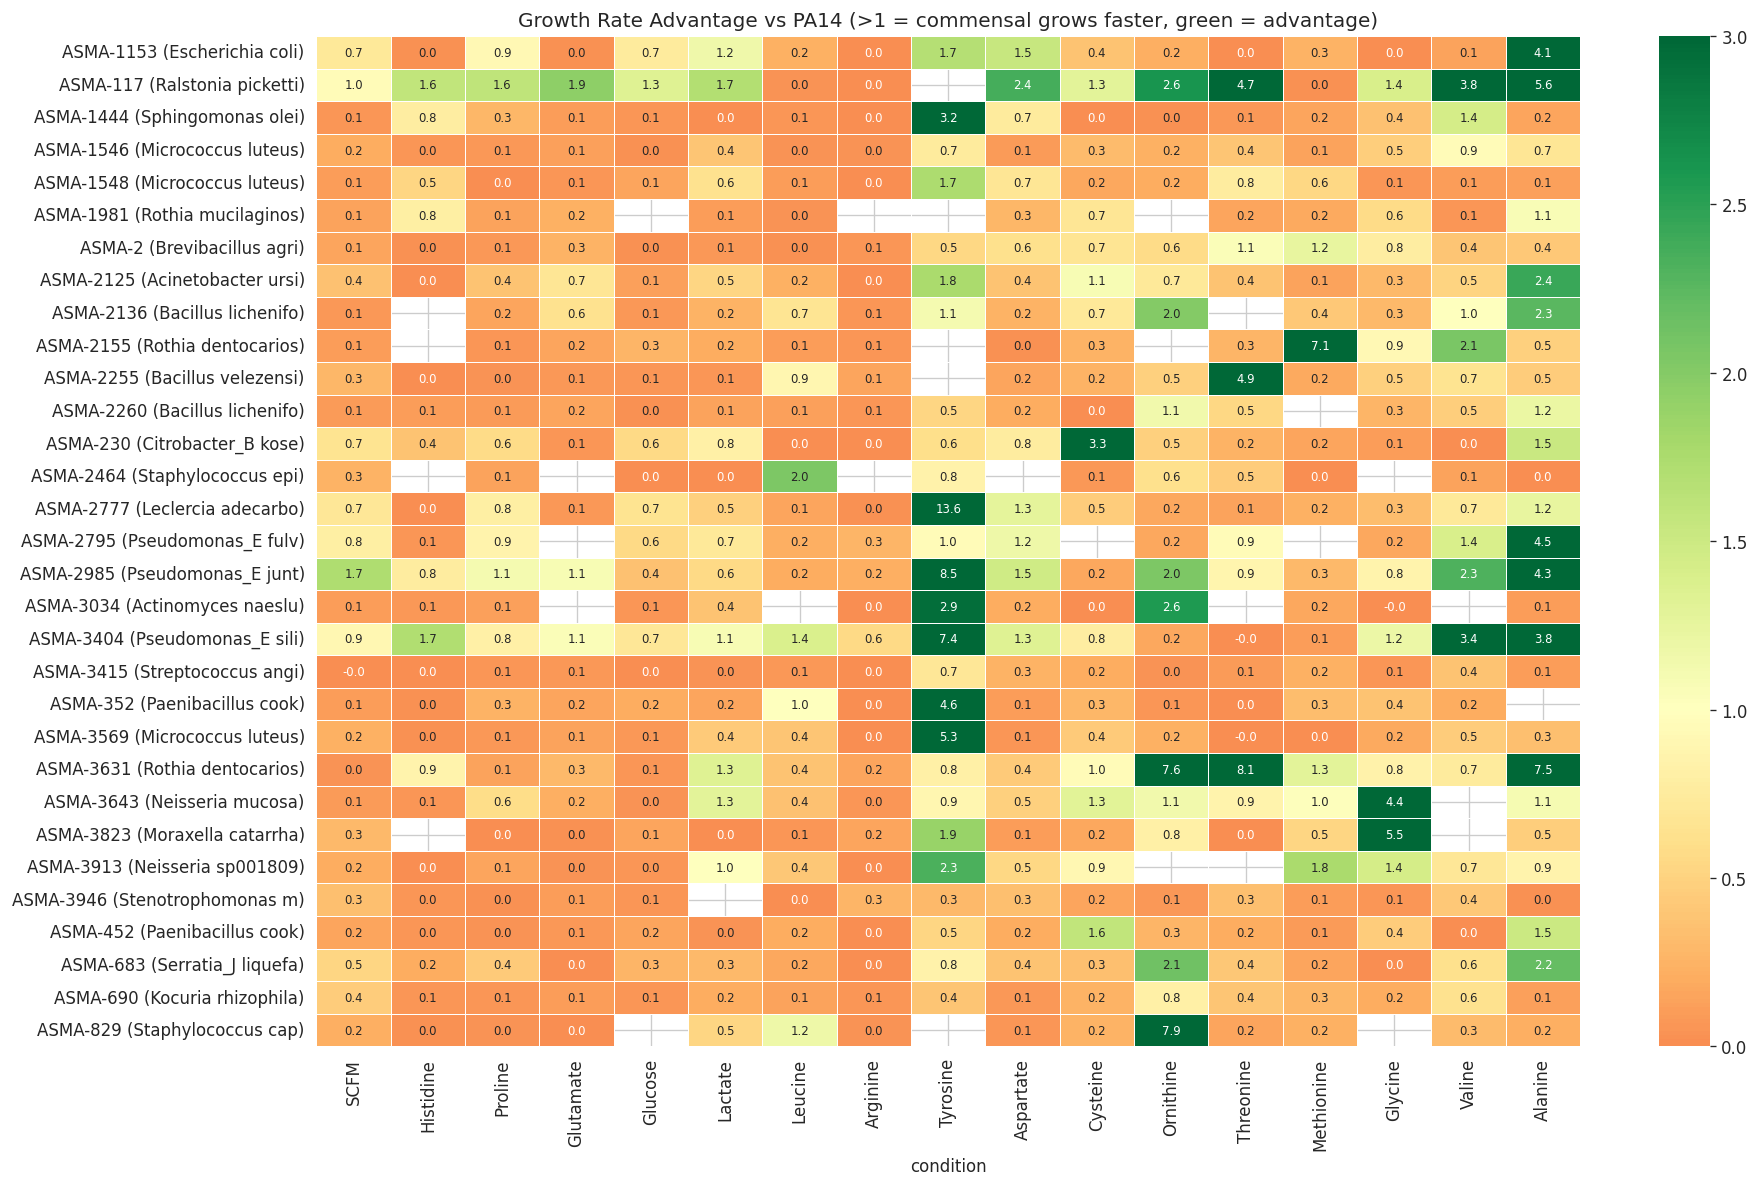

In [7]:
# Heatmap: rate advantage per isolate x condition
rate_pivot = adv.pivot_table(index='asma_id', columns='condition', values='rate_advantage')
# Add species labels
sp_map = adv.drop_duplicates('asma_id').set_index('asma_id')['species']
rate_pivot.index = [f"{idx} ({sp_map.get(idx, '?')[:18]})" for idx in rate_pivot.index]

# Order columns by PA14 preference
pa14_order = pa14_params.sort_values('K', ascending=False).index.tolist()
col_order = [c for c in pa14_order if c in rate_pivot.columns]
rate_pivot = rate_pivot[col_order]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(rate_pivot, cmap='RdYlGn', center=1.0, vmin=0, vmax=3,
            linewidths=0.3, ax=ax, annot=True, fmt='.1f', annot_kws={'size': 7})
ax.set_title('Growth Rate Advantage vs PA14 (>1 = commensal grows faster, green = advantage)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / '02_rate_advantage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Per-isolate summary: mean kinetic advantage across PA14-preferred substrates
pa14_pref_conds = ['Proline', 'Histidine', 'Ornithine', 'Glutamate', 'Aspartate', 
                   'Isoleucine', 'Arginine']
adv_pref = adv[adv.condition.isin(pa14_pref_conds)]
isolate_kinetic = adv_pref.groupby('asma_id').agg(
    mean_rate_advantage=('rate_advantage', 'mean'),
    mean_lag_advantage=('lag_advantage', 'mean'),
    mean_auc_advantage=('auc_advantage', 'mean'),
    n_faster=('rate_advantage', lambda x: (x > 1).sum()),
    n_substrates=('rate_advantage', 'count'),
    species=('species', 'first')
).reset_index()

print('Per-isolate kinetic summary (PA14-preferred substrates only):')
print(isolate_kinetic.sort_values('mean_rate_advantage', ascending=False).to_string(index=False))

Per-isolate kinetic summary (PA14-preferred substrates only):
  asma_id  mean_rate_advantage  mean_lag_advantage  mean_auc_advantage  n_faster  n_substrates                        species
 ASMA-117             1.688330          -15.775551            1.111564         5             6          Ralstonia pickettii_B
ASMA-3631             1.572015           -1.154309            1.479870         1             6            Rothia dentocariosa
 ASMA-829             1.347438          -25.834526            0.519202         1             6         Staphylococcus capitis
ASMA-2985             1.117894            5.166905            0.944869         4             6         Pseudomonas_E juntendi
ASMA-3404             0.941949           -2.473518            1.432718         3             6        Pseudomonas_E siliginis
ASMA-2136             0.620153          -14.685371            0.676780         1             5         Bacillus licheniformis
ASMA-3034             0.591538          -10.080962      

## 4. Kinetics vs Endpoint OD

Do growth kinetic features add information beyond what endpoint OD already captures?

In [9]:
# Load carbon utilization endpoint data for the 32 growth curve isolates
cu = pd.read_parquet(GOLD / 'fact_carbon_utilization.snappy.parquet')
carbon_sources_lower = {c.lower(): c for c in cu.columns if c not in ['sample_id','asma_id','assay_start_date']}

# Melt CU data
cu_melt = cu.melt(id_vars=['asma_id','sample_id','assay_start_date'], 
                  value_vars=[c for c in cu.columns if c not in ['sample_id','asma_id','assay_start_date']],
                  var_name='condition_lower', value_name='endpoint_od')
cu_melt['endpoint_od'] = pd.to_numeric(cu_melt['endpoint_od'], errors='coerce')
cu_melt['condition'] = cu_melt['condition_lower'].str.capitalize()
cu_melt.loc[cu_melt.condition == 'No_carbon', 'condition'] = 'No carbon'
cu_melt.loc[cu_melt.condition == 'Cystein', 'condition'] = 'Cysteine'

# Mean endpoint per isolate x condition
cu_mean = cu_melt.groupby(['asma_id','condition'])['endpoint_od'].mean().reset_index()

# Merge with kinetic params
compare = params_sc.merge(cu_mean, on=['asma_id','condition'], how='inner')
print(f'Matched: {len(compare)} isolate × condition pairs with both kinetic params and endpoint OD')

# Correlations
from scipy import stats
for param in ['K', 'mu_max', 'auc']:
    valid = compare.dropna(subset=[param, 'endpoint_od'])
    r, p = stats.pearsonr(valid[param], valid['endpoint_od'])
    print(f'{param} vs endpoint_od: r={r:.3f}, p={p:.2e} (n={len(valid)})')

Matched: 596 isolate × condition pairs with both kinetic params and endpoint OD
K vs endpoint_od: r=0.405, p=6.60e-25 (n=596)
mu_max vs endpoint_od: r=0.392, p=2.37e-23 (n=596)
auc vs endpoint_od: r=0.399, p=3.27e-24 (n=596)


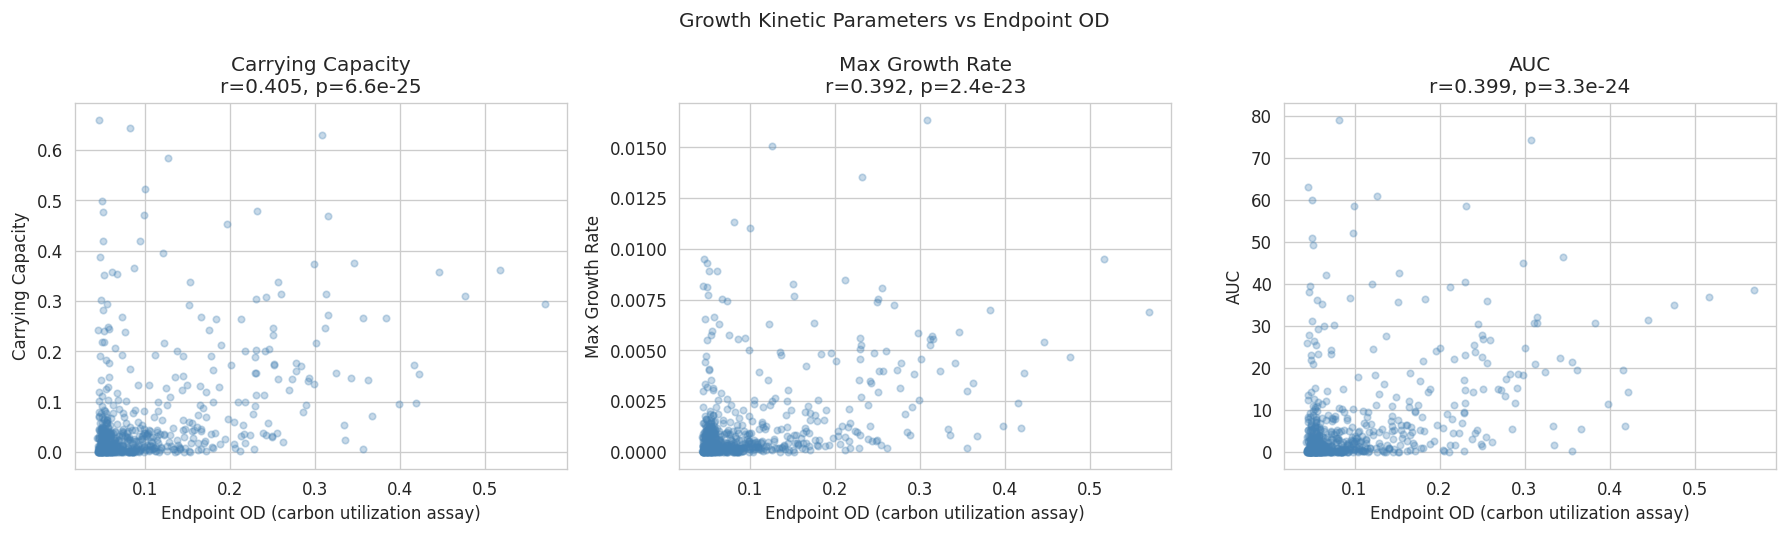

In [10]:
# Scatter: mu_max vs endpoint OD (are they redundant?)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, (param, label) in enumerate([('K', 'Carrying Capacity'), ('mu_max', 'Max Growth Rate'), ('auc', 'AUC')]):
    ax = axes[i]
    valid = compare.dropna(subset=[param, 'endpoint_od'])
    ax.scatter(valid['endpoint_od'], valid[param], alpha=0.3, s=15, color='steelblue')
    r, p = stats.pearsonr(valid['endpoint_od'], valid[param])
    ax.set_xlabel('Endpoint OD (carbon utilization assay)')
    ax.set_ylabel(label)
    ax.set_title(f'{label}\nr={r:.3f}, p={p:.1e}')

plt.suptitle('Growth Kinetic Parameters vs Endpoint OD', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / '02_kinetics_vs_endpoint.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Save outputs
params_all.to_csv(DATA / 'growth_parameters.tsv', sep='\t', index=False)
adv.to_csv(DATA / 'kinetic_advantage.tsv', sep='\t', index=False)
isolate_kinetic.to_csv(DATA / 'isolate_kinetic_summary.tsv', sep='\t', index=False)

print('Saved:')
print(f'  {DATA}/growth_parameters.tsv ({len(params_all)} rows)')
print(f'  {DATA}/kinetic_advantage.tsv ({len(adv)} rows)')
print(f'  {DATA}/isolate_kinetic_summary.tsv ({len(isolate_kinetic)} rows)')
print(f'\n=== NB02 SUMMARY ===')
print(f'Growth parameters extracted for {params_sc.asma_id.nunique()} isolates × {params_sc.condition.nunique()} conditions')
print(f'Commensals beat PA14 growth rate on {(adv.rate_advantage > 1).mean():.0%} of substrate comparisons')
print(f'Growth curve isolates with kinetic data: {isolate_kinetic.asma_id.nunique()}')

Saved:
  ../data/growth_parameters.tsv (1352 rows)
  ../data/kinetic_advantage.tsv (654 rows)
  ../data/isolate_kinetic_summary.tsv (31 rows)

=== NB02 SUMMARY ===
Growth parameters extracted for 32 isolates × 22 conditions
Commensals beat PA14 growth rate on 14% of substrate comparisons
Growth curve isolates with kinetic data: 31
